In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import jn_zeros, j0, j1, erfc


def hourglass_field_kolmo(M_A, g_size, iaxis, plotting):

    # Parameters
    R_outer = 5.0
    h = 1.0
    B0 = 1.0
    Bm = 1.0
    betam = Bm / B0
    N_terms = 3

    # Stokes
    I0 = 1.0

    # Turbulence
    turb_sigma = M_A
    corr_r = 0.9

    # DCF Parameters
    rho = 1.0              # mass density (set to 1 for toy model)
    sigma_v = 1.0          # LOS velocity dispersion (required by DCF formula)
    cf_prefactor = np.sqrt(4 * np.pi * rho) * sigma_v

    # =========================
    # CARTESIAN GRID
    # =========================
    x = np.linspace(-0.25, 0.25, g_size)
    y = np.linspace(-0.25, 0.25, g_size)
    z = np.linspace(-0.25, 0.25, g_size)
    X, Y, Z = np.meshgrid(x, y, z, indexing='ij')

    R = np.sqrt(X**2 + Y**2)
    R_safe = np.where(R == 0, 1e-12, R)

    # =========================
    # BESSEL SERIES
    # =========================
    roots = jn_zeros(1, N_terms)
    weights = 2 / (roots * j0(roots)**2)
    eta = h / R_outer

    Br0 = np.zeros_like(R)
    Bz0 = np.zeros_like(R)

    for n in range(N_terms):

        lam = roots[n]
        w = weights[n]

        J0_eval = j0(lam * R)
        J1_eval = j1(lam * R)

        arg_neg = lam * eta / 2 - Z / eta
        arg_pos = lam * eta / 2 + Z / eta

        er_neg = erfc(arg_neg)
        er_pos = erfc(arg_pos)

        exp_neg = np.exp(-lam * Z)
        exp_pos = np.exp(lam * Z)

        brackets0 = er_pos * exp_pos + er_neg * exp_neg
        brackets1 = er_neg * exp_neg - er_pos * exp_pos

        Br0 += w * J1_eval * betam * brackets1
        Bz0 += w * J0_eval * betam * brackets0


    Bz0 += 1.0

    # =========================
    # CYLINDRICAL → CARTESIAN
    # =========================
    Bx0 = Br0 * (X/ R_safe)
    By0 = Br0 * (Y/ R_safe)

    # Bx0[R == 0] = 0
    # By0[R == 0] = 0

    # =========================
    # 3D KOLMOGOROV TURBULENCE (DIVERGENCE-FREE)
    # =========================

    dx = x[1] - x[0]
    dy = y[1] - y[0]
    dz = z[1] - z[0]

    kx = np.fft.fftfreq(g_size, d=dx) * 2 * np.pi
    ky = np.fft.fftfreq(g_size, d=dy) * 2 * np.pi
    kz = np.fft.fftfreq(g_size, d=dz) * 2 * np.pi
    KX, KY, KZ = np.meshgrid(kx, ky, kz, indexing="ij")

    k2 = KX**2 + KY**2 + KZ**2
    k = np.sqrt(k2)

    rng = np.random.default_rng()

    def rand_complex(shape):
        return (rng.standard_normal(shape) +
                1j * rng.standard_normal(shape)) / np.sqrt(2)

    Fx = rand_complex(X.shape)
    Fy = rand_complex(X.shape)
    Fz = rand_complex(X.shape)

    # Kolmogorov amplitude scaling
    with np.errstate(divide="ignore", invalid="ignore"):
        kolmogorov_weight = np.where(k > 0, k ** (-11.0 / 6.0), 0.0)

    Fx *= kolmogorov_weight
    Fy *= kolmogorov_weight
    Fz *= kolmogorov_weight

    # Project out longitudinal component (∇·δB = 0)
    k2_safe = np.where(k2 > 0, k2, 1.0)

    k_dot_F = KX * Fx + KY * Fy + KZ * Fz

    Fx -= KX * k_dot_F / k2_safe
    Fy -= KY * k_dot_F / k2_safe
    Fz -= KZ * k_dot_F / k2_safe

    # Back to real space
    dBx = np.fft.ifftn(Fx).real
    dBy = np.fft.ifftn(Fy).real
    dBz = np.fft.ifftn(Fz).real

    # Normalise RMS turbulence amplitude to M_A
    rms = np.sqrt(np.mean(dBx**2 + dBy**2 + dBz**2))
    if rms > 0:
        dBx *= M_A / rms
        dBy *= M_A / rms
        dBz *= M_A / rms

    # Add turbulence to large-scale field
    Bx = Bx0 + dBx
    By = By0 + dBy
    Bz = Bz0 + dBz

    # =========================
    # ENFORCE ∇·B = 0 ON TOTAL FIELD
    # =========================
    Bx_k = np.fft.fftn(Bx)
    By_k = np.fft.fftn(By)
    Bz_k = np.fft.fftn(Bz)

    k_dot_B = KX * Bx_k + KY * By_k + KZ * Bz_k

    mask = k2 > 0
    Bx_k[mask] -= KX[mask] * k_dot_B[mask] / k2[mask]
    By_k[mask] -= KY[mask] * k_dot_B[mask] / k2[mask]
    Bz_k[mask] -= KZ[mask] * k_dot_B[mask] / k2[mask]

    Bx = np.fft.ifftn(Bx_k).real
    By = np.fft.ifftn(By_k).real
    Bz = np.fft.ifftn(Bz_k).real

    # =========================
    # STOKES
    # =========================

    # Define LOS and POS components
    if iaxis == 0:        # LOS = x → POS = (y,z)
        B_los = Bx
        B1, B2 = By, Bz

    elif iaxis == 1:      # LOS = y → POS = (x,z)
        B_los = By
        B1, B2 = Bx, Bz

    else:                 # LOS = z → POS = (x,y)
        B_los = Bz
        B1, B2 = Bx, By

    B_los2  = B_los**2
    B_perp2 = B1**2 + B2**2
    Btot2   = B_perp2 + B_los2

    # Geometrical depolarization
    cos2g = B_perp2 / (Btot2 + 1e-12)
    I_local = I0 * cos2g

    # Safe division mask
    mask = B_perp2 > 1e-12

    Q = np.zeros_like(B1)
    U = np.zeros_like(B1)

    # Standard dust polarization definition
    Q[mask] = I_local[mask] * (B2[mask]**2 - B1[mask]**2) / B_perp2[mask]
    U[mask] = I_local[mask] * (2 * B1[mask] * B2[mask]) / B_perp2[mask]

    # LOS integration
    I_obs = I_local.sum(axis=iaxis)
    Q_obs = Q.sum(axis=iaxis)
    U_obs = U.sum(axis=iaxis)

    P_obs = np.sqrt(Q_obs**2 + U_obs**2) / (I_obs + 1e-12)
    phi_obs = 0.5 * np.arctan2(U_obs, Q_obs)

    # =========================
    # PLOTTING
    # =========================
    if plotting:

        skip = g_size // 10

        # 3D visualization
        fig = plt.figure()
        ax = fig.add_subplot(111, projection='3d')
        ax.quiver(
            X[::skip, ::skip, ::skip],
            Y[::skip, ::skip, ::skip],
            Z[::skip, ::skip, ::skip],
            Bx[::skip, ::skip, ::skip],
            By[::skip, ::skip, ::skip],
            Bz[::skip, ::skip, ::skip],
            length=0.05, normalize=True,linewidth=1.5, arrow_length_ratio=0)
        ax.set_title("3D Hourglass + Turbulence")
        plt.show()

        mid = g_size // 2

        fig, axes = plt.subplots(1,3,figsize=(12,4))

        # LOS = x → POS = (y,z)
        axes[0].quiver(
            Y[mid, :, :],
            Z[mid, :, :],
            By[mid, :, :],
            Bz[mid, :, :],
            headaxislength=0, headlength=0, headwidth=1, pivot='middle')
        axes[0].set_xlabel("Y")
        axes[0].set_ylabel("Z")
        axes[0].set_title("LOS X")

        # LOS = y → POS = (x,z)
        axes[1].quiver(
            X[:, mid, :],
            Z[:, mid, :],
            Bx[:, mid, :],
            Bz[:, mid, :],
            headaxislength=0, headlength=0, headwidth=1, pivot='middle')
        axes[1].set_xlabel("X")
        axes[1].set_ylabel("Z")
        axes[1].set_title("LOS Y")

        # LOS = z → POS = (x,y)
        axes[2].quiver(
            X[:, :, mid],
            Y[:, :, mid],
            Bx[:, :, mid],
            By[:, :, mid],
            headaxislength=0, headlength=0, headwidth=1, pivot='middle')
        axes[2].set_xlabel("X")
        axes[2].set_ylabel("Y")
        axes[2].set_title("LOS Z")

        plt.tight_layout()
        plt.show()


    return P_obs, phi_obs, cos2g.mean(axis=iaxis)


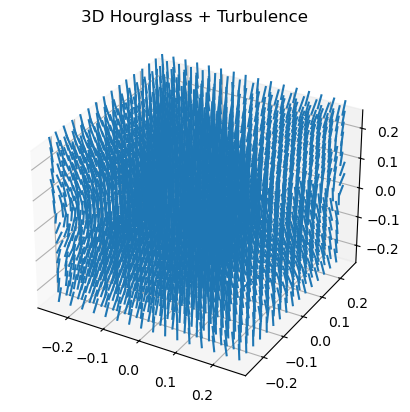

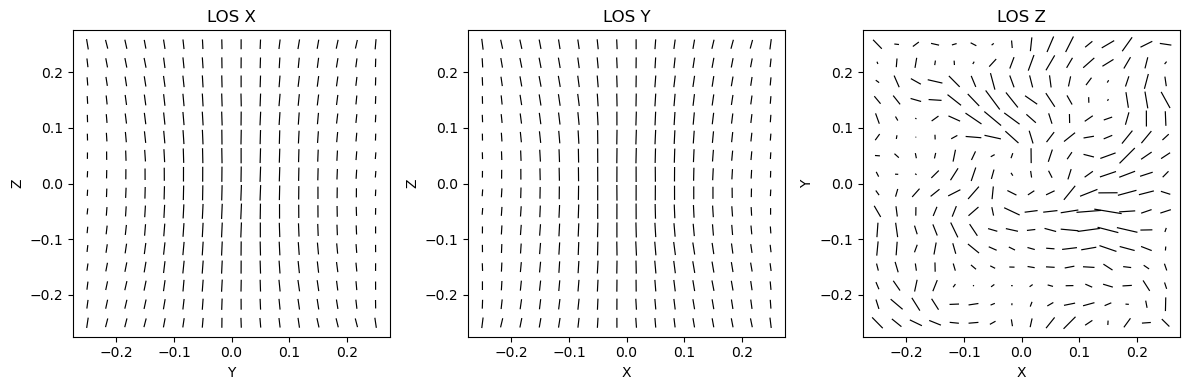

In [2]:
P,PHI,COS = hourglass_field_kolmo(M_A=0.25, g_size=16, iaxis=0, plotting=True)

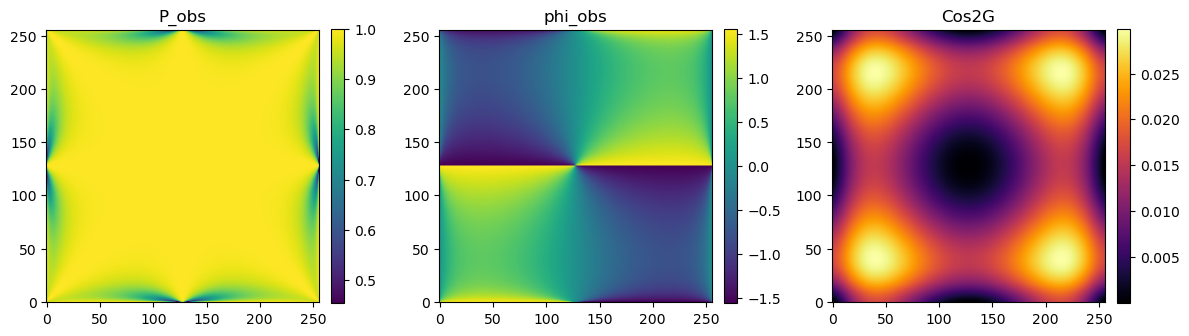

In [8]:
gsize = 64
P,PHI,COS = hourglass_field_kolmo(M_A=0.0, g_size=256, iaxis=2, plotting=False)

fig, axs = plt.subplots(1,3,figsize=(12,4))

im0 = axs[0].imshow(P.T, cmap='viridis',origin='lower')
plt.colorbar(im0, ax=axs[0], fraction=0.046, pad=0.04)
axs[0].set_title('P_obs')
# axs[0].set_ylim(0,gsize)

im1 = axs[1].imshow(PHI.T, cmap='viridis', origin='lower')
plt.colorbar(im1, ax=axs[1], fraction=0.046, pad=0.04)
axs[1].set_title('phi_obs')
# axs[1].set_ylim(0,gsize)

im2 = axs[2].imshow(COS.T, cmap='inferno',origin='lower')
plt.colorbar(im2, ax=axs[2], fraction=0.046, pad=0.04)
axs[2].set_title('Cos2G')
# axs[2].set_ylim(0,gsize)

plt.tight_layout()

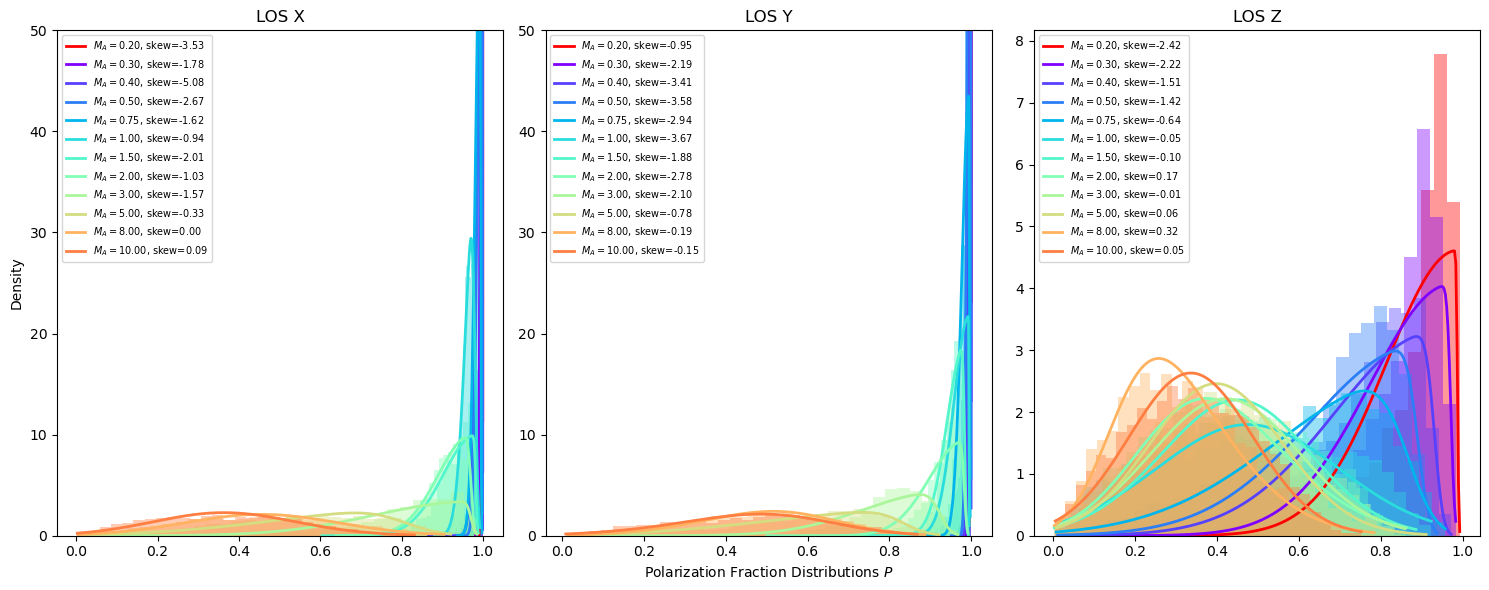

In [30]:
from scipy.stats import skew, skewnorm
# mach_vals = [0,0.01,0.02,0.05]
mach_vals = [0.2,0.3, 0.4, 0.5,0.75,1,1.5,2,3,5,8,10]
color = plt.cm.rainbow(np.linspace(0,1,len(mach_vals)+1))

fig, axes = plt.subplots(1,3,figsize=(15,6))

for nax in range(3):
    for imach in mach_vals:

        # simulate
        P, PHI, COS = hourglass_field_kolmo(M_A=imach, g_size=64, iaxis=nax, plotting=False)

        # flatten & clip to >0
        Pflat = P.flatten()
        Pflat = Pflat[Pflat > 0]

        # --- compute raw skewness ---
        skew_val = skew(Pflat, bias=False)

        # --- fit skewnormal distribution ---
        # skewnorm.fit returns (a, loc, scale)
        a, loc, scale = skewnorm.fit(Pflat)

        # build PDF for plotting
        x = np.linspace(Pflat.min(), Pflat.max(), 300)
        pdf_skew = skewnorm.pdf(x, a, loc=loc, scale=scale)

        # --- histogram ---
        axes[nax].hist(Pflat, bins=30, density=True, alpha=0.4, color = color[mach_vals.index(imach)-1])

        # plt.hist(Pflat, bins=30, density=True, alpha=0.4, color = color[mach_vals.index(imach)-1])

        # --- overlay skewnormal fit ---
        axes[nax].plot(x, pdf_skew, lw=2, label=rf"$M_A={imach:.2f}$, skew={skew_val:.2f}", color=color[mach_vals.index(imach)-1])

    axes[nax].legend(fontsize=7)

axes[1].set_xlabel("Polarization Fraction Distributions $P$")
axes[0].set_ylabel("Density")
axes[0].set_title('LOS X')
axes[1].set_title('LOS Y')
axes[2].set_title('LOS Z')
# axes[0].yscale("log")
axes[0].set_ylim(0,50)
axes[1].set_ylim(0,50)
# axes[2].set_ylim(0,1e4)
# plt.title('Uniform Field: Polarization Distributions for Varying Mach #')
plt.tight_layout()
plt.show()


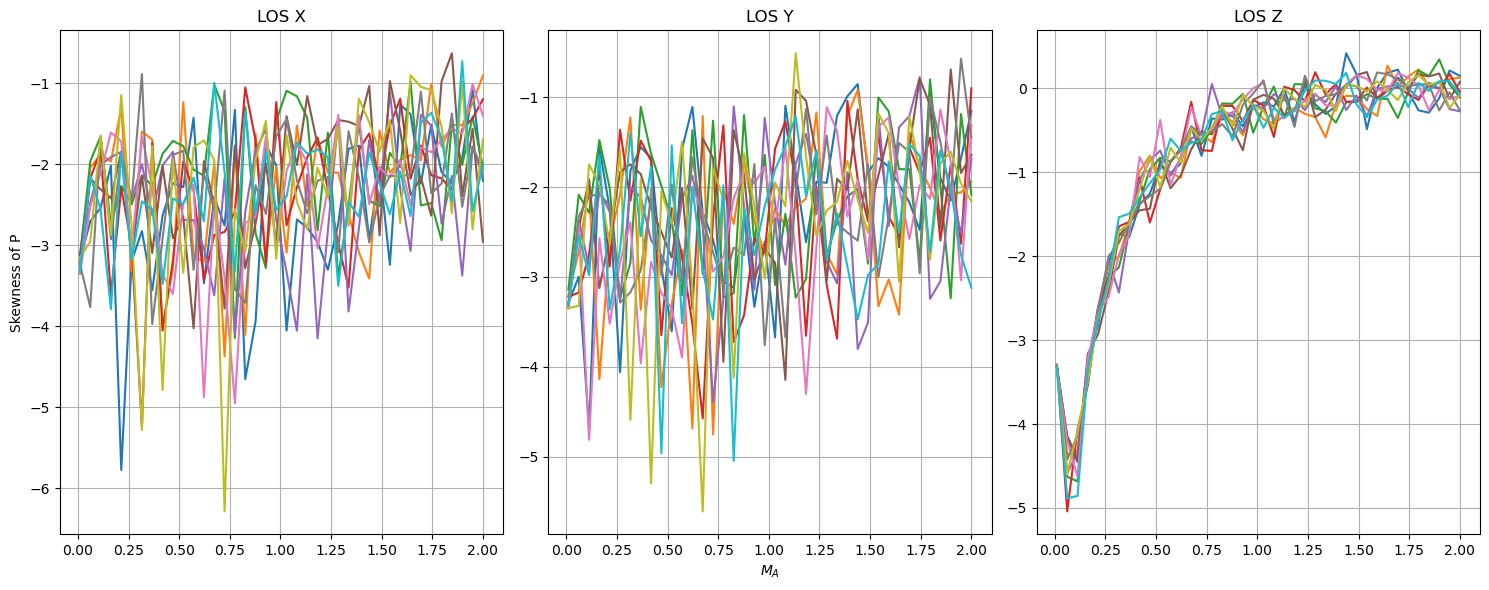

In [26]:
n = 10
fig, axes = plt.subplots(1,3,figsize=(15,6))
mach_vals = np.linspace(0.01,2,40)

for nax in range(3):
    for i in range(n):
        skews = []
        for imach in mach_vals:
            P, PHI, COS = P, PHI, COS = hourglass_field_kolmo(M_A=imach, g_size=64, iaxis=nax, plotting=False)
            skews.append(skew(P.flatten(), bias=False))
        axes[nax].plot(mach_vals, skews, linestyle='-')

axes[1].set_xlabel(r"$M_A$")
axes[0].set_ylabel("Skewness of P")

axes[0].set_title('LOS X')
axes[1].set_title('LOS Y')
axes[2].set_title('LOS Z')

axes[0].grid()
axes[1].grid()
axes[2].grid()
plt.tight_layout()
plt.show()
